# Collider-ring validation studies

Validation of the MINT muon-decay/neutrino-flux simulation on the 10 TeV muon-collider
ring shipped with the package (`mc_10tev_hybrid_v06`, MAD-X twiss `ir1ccma_hybrid_v06`).

This notebook contains only the core validation plots:

1. **Lattice geometry** — closed orbit in the world frame, interaction point (IP) at the origin.
2. **Beam optics** — RMS beam envelope and divergence from the Twiss functions (low-beta waist at the IP).
3. **Forward neutrino flux** — energy spectrum at a detector 1 km downstream, with and without beam dynamics.
4. **Event rates** — radial distribution (with MC uncertainties) and energy spectrum of interactions in a forward detector.
5. **Energy vs radius map** — 2D distribution of events at the detector plane.

Extended studies (straightened lattice, chicane removal, comparisons with past experiments)
live in `dev_examples/collider_ring_studies_extended.ipynb`.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import vector

import mint
from mint import const, xsecs
from mint import plot_tools as pt
from mint.MuC import MuDecaySimulator

os.makedirs("plots", exist_ok=True)

## 1. Load the collider-ring lattice

Lattices shipped with MINT are listed by `mint.lattices.available()` and loaded by name.
The loader parses the MAD-X TFS/TWISS table, integrates the survey geometry, smooths the
Twiss functions into beam envelopes/divergences, and attaches the default operational
beam parameters (overridable via keyword arguments).

In [2]:
for name, desc in mint.lattices.available().items():
    print(f"{name}: {desc}")

ring = mint.lattices.load("mc_10tev_hybrid_v06")

print(f"\nLattice: {ring.name}")
print(f"Circumference: {ring.s(1) / 1e5:.3f} km")
print(f"Beam momentum: {float(ring.beam_p0(0.5)):.0f} GeV")
print(f"Muons per bunch: {ring.Nmu_per_bunch:.1e}")
print(f"Injection frequency: {ring.finj} Hz, duty factor: {ring.duty_factor:.3f}")
print(f"Machine circumference: {ring.total_circumference / 1e5:.1f} km "
      f"(lattice covers {ring.s(1) / ring.total_circumference:.1%})")

mc_10tev_hybrid_v06: 10 TeV muon collider interaction region, hybrid IR design v06 (MAD-X twiss: ir1ccma_hybrid_v06; covers ~1.5 km of the 10 km ring)
mc_10tev_IR_v09: 10 TeV muon collider interaction region only, v09 (sublattice of the 10 km ring)

Lattice: mc_10tev_hybrid_v06
Circumference: 1.465 km
Beam momentum: 5000 GeV
Muons per bunch: 2.0e+12
Injection frequency: 5.0 Hz, duty factor: 0.318
Machine circumference: 10.0 km (lattice covers 14.6%)


## 2. Lattice geometry

World coordinates: $x$ toward the ring center, $y$ vertical, $z$ tangential at the IP.
The closed orbit must be smooth and the IP must sit at the origin.

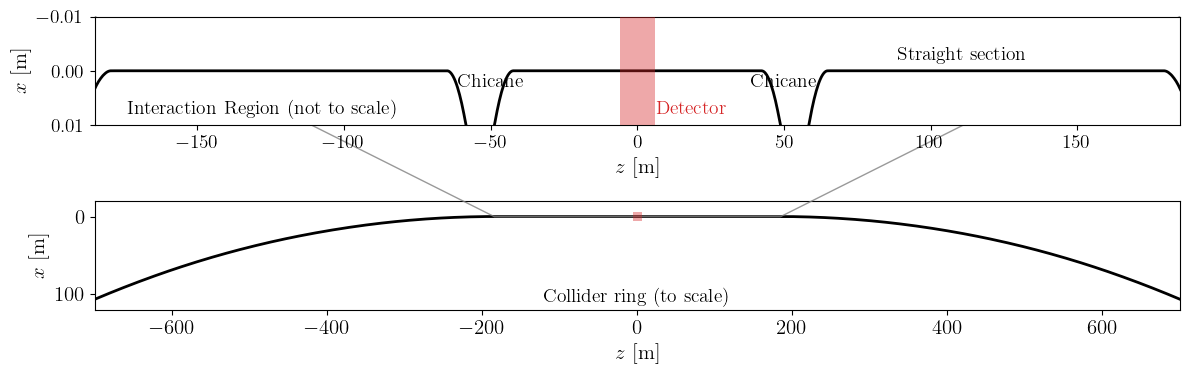

In [3]:
# Quick geometry and reference momentum profile
u = np.linspace(0, 1, 4000)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.plot(ring.z(u)/100, ring.x(u)/100, lw=2.0, color='black')
ax.set_xlabel(r"$z$ [m]", fontsize=15)
ax.set_ylabel(r"$x$ [m]", fontsize=15)
ax.tick_params(labelsize=15)
ax.text(0.5, 0.07, "Collider ring (to scale)", transform=ax.transAxes, ha="center", fontsize=14)
ax.set_xlim(-700, 700)
ax.set_ylim(120, -20)
ax.set_aspect("equal", adjustable="box")

# Detector box: ±6 m around IP (0, 0)
det_half = 6  # meters
det_box = plt.Rectangle((-det_half, -det_half), 2*det_half, 2*det_half,
                         linewidth=1.5, edgecolor='None', facecolor='tab:red', alpha=0.4, zorder=5)
ax.add_patch(det_box)

# Inset: chicane detail at ~x=50m, y~20cm
xl = 0.12
axins = ax.inset_axes([0, 1.7, 1, 1])
axins.plot(ring.z(u)/100, ring.x(u)/100, lw=2, color='black')
axins.set_xlim(-185, 185)
axins.set_ylim(0.01, -0.01)
axins.tick_params(labelsize=14)
axins.set_xlabel(r"$z$ [m]", fontsize=15)
axins.set_ylabel(r"$x$ [m]", fontsize=15)
ax.indicate_inset_zoom(axins, edgecolor="gray", alpha=0.8)

# Detector box in inset
det_box_ins = plt.Rectangle((-det_half, -det_half), 2*det_half, 2*det_half,
                              linewidth=1.5, edgecolor='None', facecolor='tab:red', alpha=0.4, zorder=5)
axins.add_patch(det_box_ins)
# axins.set_aspect("equal", adjustable="box")
axins.text(0.8, 0.6, "Straight section", transform=axins.transAxes, ha="center", fontsize=14)
axins.text(0.365, 0.35, "Chicane", transform=axins.transAxes, ha="center", fontsize=14)
axins.text(1-0.365, 0.35, "Chicane", transform=axins.transAxes, ha="center", fontsize=14)
axins.text(0.55, 0.1, "Detector", transform=axins.transAxes, ha="center", fontsize=14, color="tab:red")
axins.text(0.03, 0.1, "Interaction Region (not to scale)", transform=axins.transAxes, ha="left", fontsize=14)

fig.tight_layout()
fig.savefig("plots/collider_ring_geometry.pdf", dpi=400, bbox_inches="tight")

## 3. Beam optics

RMS beam envelope $\sigma_{x,y}(s) = \sqrt{\epsilon\, \beta_{x,y}(s)}$ and divergence
$\sigma'_{x,y}(s) = \sqrt{\epsilon\, \gamma_{x,y}(s)}$. The envelope must show the
low-beta waist at the IP with the corresponding spike in divergence.

(<Figure size 900x300 with 1 Axes>,
 <Axes: xlabel='Distance to IP [m]', ylabel='beam divergence [rad]'>)

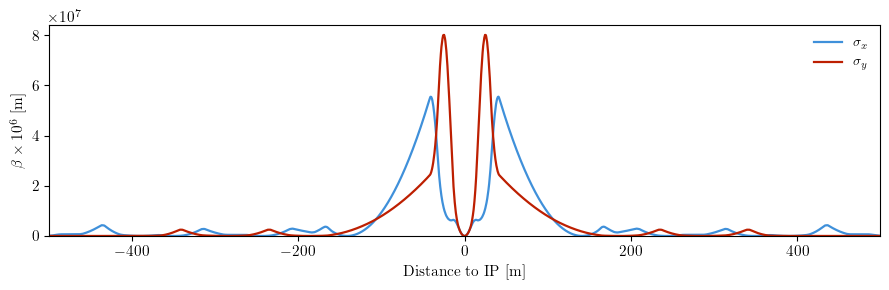

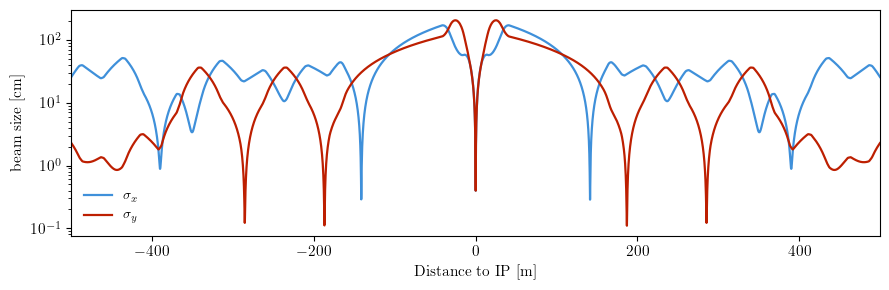

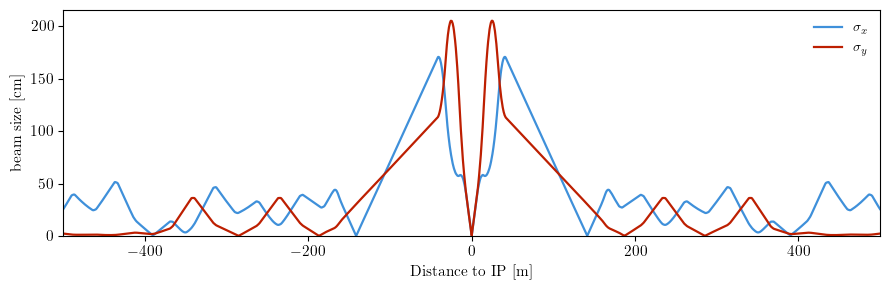

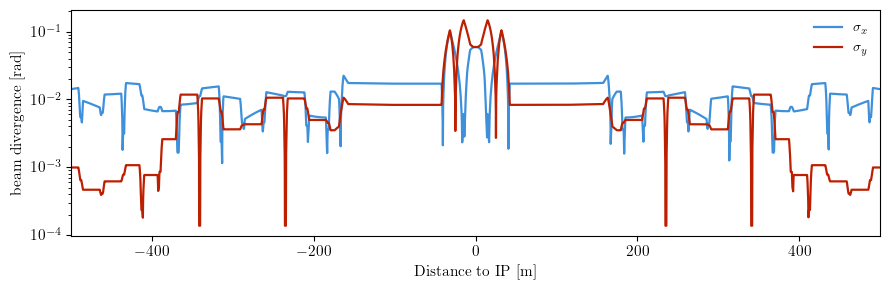

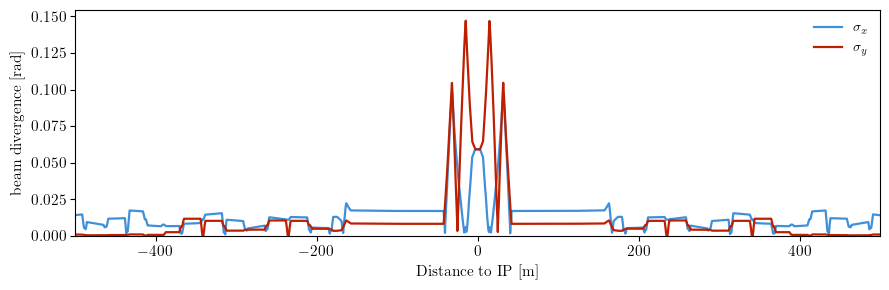

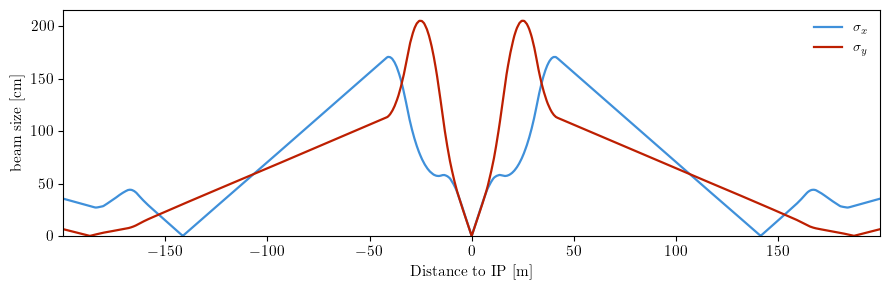

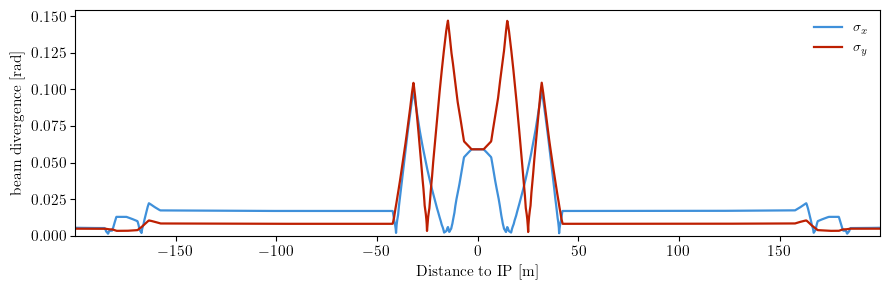

In [4]:
def plot_beam_optics(ring, u, property="beamsize", s_range_cm=(-100e2, 100e2), n_points=10_000, logx=False, logy=False):
    u = np.linspace(0, 1, n_points)

    # Plot beam envelope (RMS) vs longitudinal position s [m]
    lo, hi = (s_range_cm[0], s_range_cm[1])
    s_IP_cm = ring.s(u).mean()
    s_cm = ring.s(u) - s_IP_cm
    sel = (s_cm >= lo) & (s_cm <= hi)
    sigma_y = np.asarray(getattr(ring, f"{property}y")(u[sel])) * 1e2  # convert to cm
    sigma_x = np.asarray(getattr(ring, f"{property}x")(u[sel])) * 1e2  # convert to cm

    fig_env, ax_env = plt.subplots(figsize=(9, 3))
    ax_env.plot(s_cm[sel]*1e-2, sigma_x, label=r"$\sigma_x$", lw=1.6)
    ax_env.plot(s_cm[sel]*1e-2, sigma_y, label=r"$\sigma_y$", lw=1.6)
    ax_env.set_xlabel("Distance to IP [m]")
    
    if property == "beamsize_":
        ax_env.set_ylabel("beam size [cm]")
    elif property == "beamdiv_":
        ax_env.set_ylabel("beam divergence [rad]")
    elif property == "bet":
        ax_env.set_ylabel(r"$\beta \times 10^{6}$ [m]")
    ax_env.legend(frameon=False)
    ax_env.set_xlim(s_cm[sel].min()*1e-2, s_cm[sel].max()*1e-2)
    if not logy:
        ax_env.set_ylim(0,)
    if logx:
        ax_env.set_xscale("log")
    if logy:
        ax_env.set_yscale("log")
    fig_env.tight_layout()
    return fig_env, ax_env

plot_beam_optics(ring, u, property='bet', s_range_cm=(-500e2, 500e2))
plot_beam_optics(ring, u, property='beamsize_', s_range_cm=(-500e2, 500e2), logy=True)
plot_beam_optics(ring, u, property='beamsize_', s_range_cm=(-500e2, 500e2), logy=False)

plot_beam_optics(ring, u, property='beamdiv_', s_range_cm=(-500e2, 500e2), logy=True)
plot_beam_optics(ring, u, property='beamdiv_', s_range_cm=(-500e2, 500e2), logy=False)

plot_beam_optics(ring, u, property='beamsize_', s_range_cm=(-200e2, 200e2), logy=False)
plot_beam_optics(ring, u, property='beamdiv_', s_range_cm=(-200e2, 200e2), logy=False)

/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_50055/3249301171.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


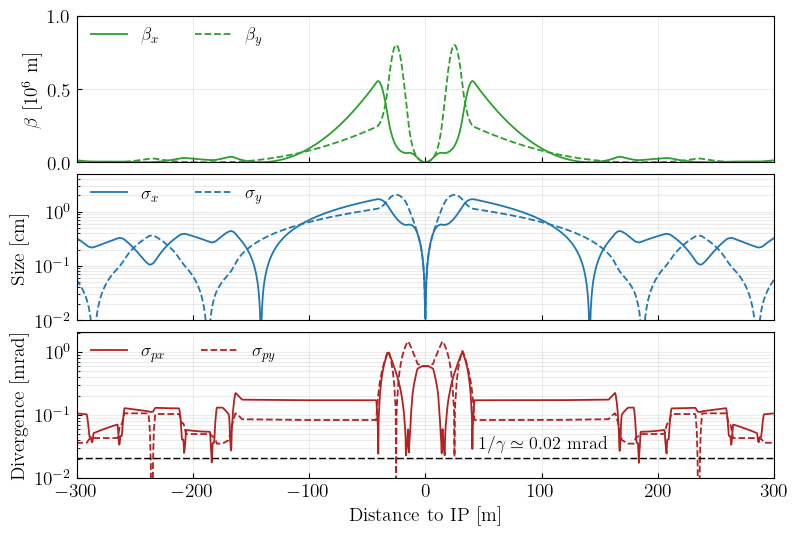

In [17]:
# Three-panel plot: beta function (top), envelope (middle), divergence (bottom), shared x-axis
s_max = 300  # meters
delta_s_m = (ring.s(u) - ring.s(u).mean()) * 1e-2

beta_x = ring.betx(u)
beta_y = ring.bety(u)
sigma_x = ring.beamsize_x(u)
sigma_y = ring.beamsize_y(u)
sigma_x_mrad = ring.beamdiv_x(u) * 1e3
sigma_y_mrad = ring.beamdiv_y(u) * 1e3

fig, (ax_beta, ax_top, ax_bot) = plt.subplots(
    3,
    1,
    figsize=(9, 6),
    sharex=True,
    gridspec_kw={"hspace": 0.08},
)

# Top panel: beta functions
ax_beta.plot(delta_s_m, beta_x*1e-6, label=r"$\beta_x$", lw=1.3, color="tab:green", linestyle="-")
ax_beta.plot(delta_s_m, beta_y*1e-6, label=r"$\beta_y$", lw=1.3, color="tab:green", linestyle="--")
ax_beta.set_ylabel(r"$\beta$ [$10^6$ m]", fontsize=14)
ax_beta.tick_params(axis="both", which="both", labelsize=14, direction="in")
# ax_beta.set_yscale("log")
ax_beta.set_ylim(0, 1.0)
ax_beta.legend(loc=(0.01, 0.75), frameon=False, fontsize=13, ncols=2)
ax_beta.grid(which="both", alpha=0.25)

# Middle panel: beam envelope
ax_top.plot(delta_s_m, sigma_x, label=r"$\sigma_x$", lw=1.3, color="tab:blue", linestyle="-")
ax_top.plot(delta_s_m, sigma_y, label=r"$\sigma_y$", lw=1.3, color="tab:blue", linestyle="--")
ax_top.set_ylabel("Size [cm]", fontsize=14)
ax_top.tick_params(axis="both", which="both", labelsize=14, direction="in")
ax_top.set_ylim(1e-2, 5)
ax_top.set_yscale("log")
ax_top.legend(loc=(0.01, 0.75), frameon=False, fontsize=13, ncols=2)
ax_top.grid(which="both", alpha=0.25)

# Bottom panel: beam divergence
ax_bot.plot(delta_s_m, sigma_x_mrad, label=r"$\sigma_{px}$", lw=1.3, color="firebrick", linestyle="-")
ax_bot.plot(delta_s_m, sigma_y_mrad, label=r"$\sigma_{py}$", lw=1.3, color="firebrick", linestyle="--")
ax_bot.set_ylabel("Divergence [mrad]", fontsize=14)
ax_bot.set_xlabel("Distance to IP [m]", fontsize=14)
ax_bot.set_yscale("log")
ax_bot.set_ylim(0.01, None)
ax_bot.set_xlim(delta_s_m.mean() - s_max, delta_s_m.mean() + s_max)
ax_bot.legend(loc=(0.01, 0.75), frameon=False, fontsize=13, ncols=2)
ax_bot.grid(which="both", alpha=0.25)
ax_bot.tick_params(axis="both", which="both", labelsize=14, direction="in")

ax_bot.hlines(
    y=(0.105 / 5e3 * 1e3),
    xmin=delta_s_m.mean() - s_max,
    xmax=delta_s_m.mean() + s_max,
    color="black",
    linestyle=(1, (5, 2)),
    lw=1.0,
)
ax_bot.annotate(
    r"$1/\gamma \simeq 0.02$~mrad",
    xy=(0.67, 0.2),
    xycoords="axes fraction",
    ha="center",
    fontsize=13,
    color="black",
)

fig.tight_layout()
fig.savefig("plots/hybrid_v06_beta_envelope_and_divergence.pdf", dpi=300, bbox_inches="tight")


## 4. Simulate the forward neutrino flux

Decay $\mu^+$ along the ring (clockwise beam): $\mu^+ \to e^+\, \nu_e\, \bar\nu_\mu$.

**vegas runs only once.** The event generation samples the 2D rest-frame Michel
distribution $(x, \cos\theta)$; flavor, polarization, and NLO enter only as
matrix-element factors, so all other cases are obtained by *exact reweighting* of the
same sample (`reweighted_copy`), and lattice placement is redone per case. The sample
can also be written to disk with `sim.save_events("events.npz")` and reloaded later
with `MuDecaySimulator.load_events(...)` -- no new vegas run ever needed.

In [6]:
N_EVALS = 2e6   # MC statistics; lower (e.g. 5e5) for quick runs

In [7]:
# One vegas run generates the master decay sample (here: numubar, P = 0).
# cycles="full_injection" simulates one injection period (1/finj seconds):
# the number of 10 km machine turns is computed from ring.total_circumference.
sim_base = MuDecaySimulator(
    muon_polarization=0.0,
    nuflavor="numubar",
    lattice=ring,
    cycles="full_injection",
    n_evals=N_EVALS,
    beam_dynamics=True,
)
print(f"machine turns per injection period: {sim_base.cycles:.0f}")
sim_base.decay_muons()
print(f"vegas sample generated: {sim_base.sample_size} events")

# All other cases reuse the sample via exact matrix-element reweighting
sims = {"numubar": sim_base}
sims["nue"] = sim_base.reweighted_copy(nuflavor="nue")
sims["numubar_nobd"] = sim_base.reweighted_copy()   # same physics, placed without beam dynamics
sims["numubar_nobd"].beam_dynamics = False

for key, sim in sims.items():
    sim.place_muons_on_lattice(lattice=ring, direction="clockwise")
    print(f"placed {key} ({sim.sample_size} MC events)")

machine turns per injection period: 5996
vegas sample generated: 1874688 events


/Users/mhostert/Repos/MINT/mint/MuC.py:442: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


placed numubar (1874688 MC events)
placed nue (1874688 MC events)
placed numubar_nobd (1874688 MC events)
